link to drive: https://drive.google.com/drive/folders/1xTfNreIPm--WQ_ZAO94Bc36u_1LZyYgS

In [1]:
#Steps for setup:
#1) "git pull" (before anything to avoid causing bugs)
#2) Make whatever changes you need to
#3) "git add ." then "git commit -m 'whatever message you want'", "git push"

#Samat - data management
#Arif - Analysis
#Tom - Analysis {Calculate basic statistics, Fuel efficiency metrics}
#Brendan - Visualization

What car do you want to see? [sedan, suv, sports]:  sports
What kind of graph do you want to produce? ['all', 'individual'] ('all' produces graphs with all car types):  all



Vehicle Analysis Report

Vehicle Speed Analysis:
 - Average Speed: 71.33667608027494 km/hr
 - Maximum Speed: 130.0890983250277 km/hr

Vehicle Acceleration Analysis:
 - Average Acceleration: -0.023392755838314173 m/s²
 - Maximum Acceleration: 59.23226829519635 m/s²

Vehicle EngineRPM Analysis:
 - Average EngineRPM: 1733.2669858939014 RPM
 - Maximum EngineRPM: 2445.5430891107844 RPM

Vehicle Fuel Consumption Analysis:
 - Average Fuel Consumption: 10.544530996881297 L
 - Maximum Fuel Consumption: 51.6158059286611 L

Vehicle Distance Analysis:
 - Average Distance: 12579.912943272731 km
 - Maximum Distance: 23778.89202675856 km

Traffic Violations:
 - Number of Traffic Violations: 0
 - Counts of Reckless Driving: 0



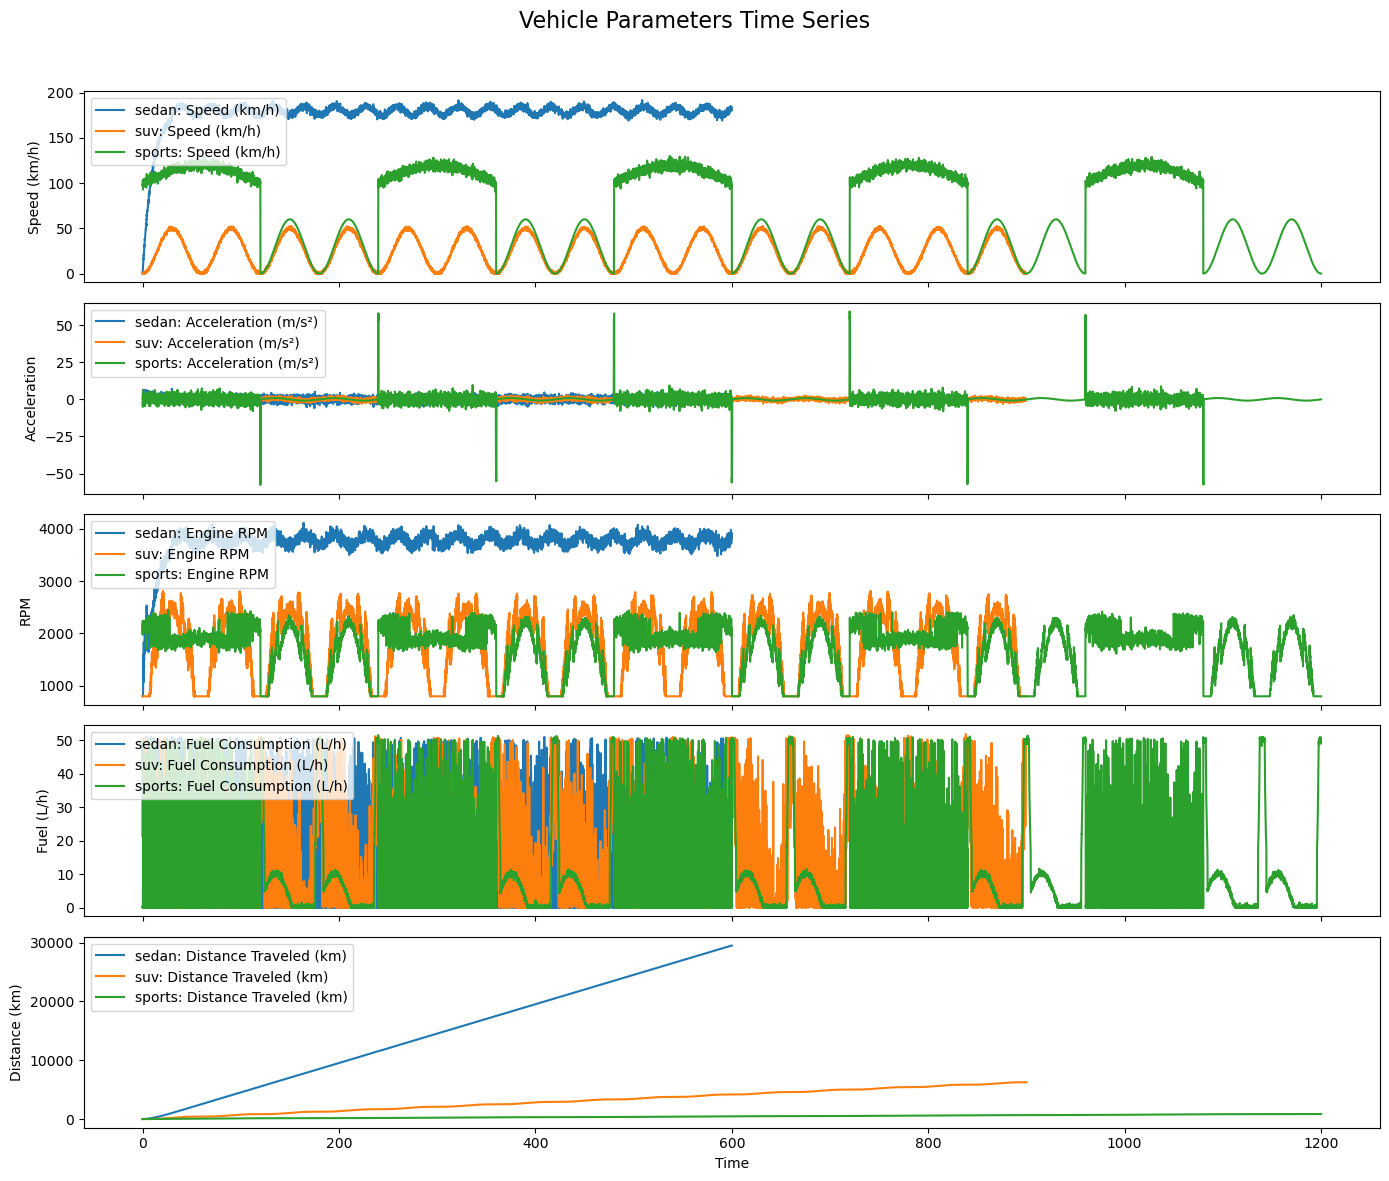

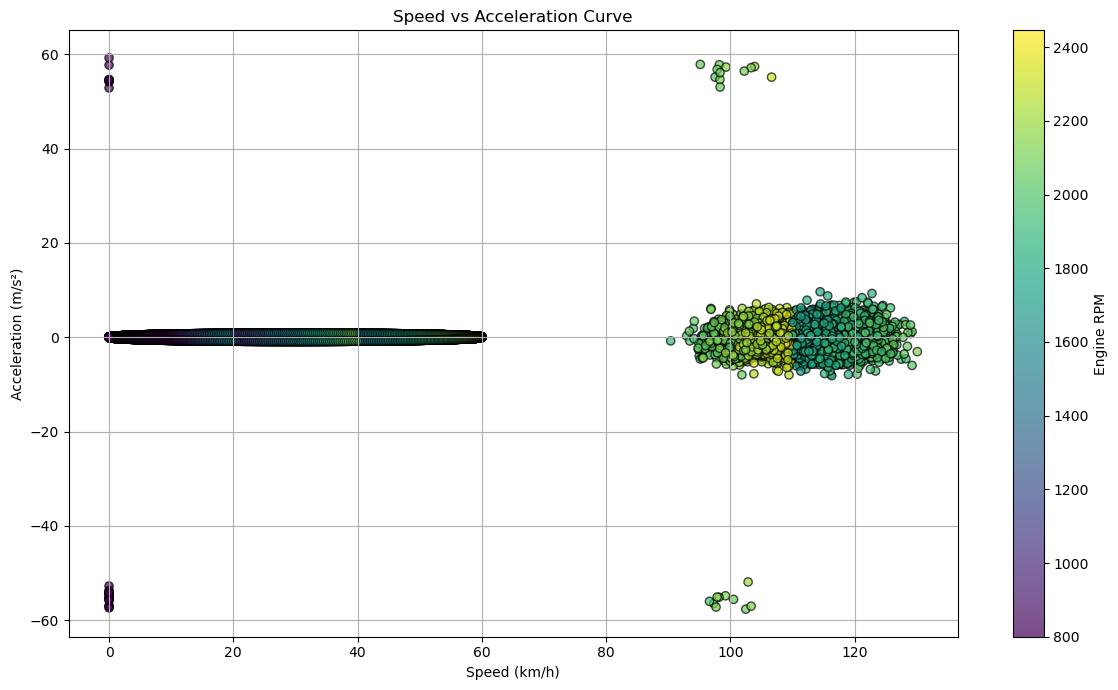

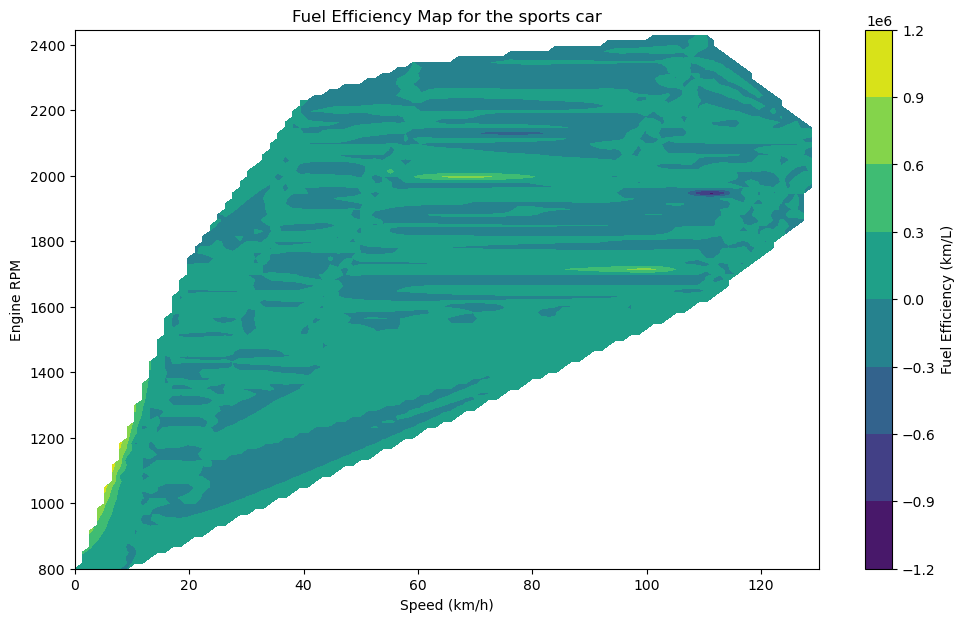

In [47]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

df = pd.read_csv("vehicle_dynamics_data.csv")

#Data management (reading from .csv)
def read_vehicle_data(filename): #function for reading the data file
    vehicle_data = {} #dictionary that is ultimately returned
    with open(filename, "r") as file: #reads the file
        data = file.readlines() 
        
    data_list = [] #here to seperate things by , from data ^^^
    for i in range(len(data)):
        data_list.append(data[i].split(","))

    for i in data_list[0]: #loops through data_list[0] which is the first line in the file with all the key names
        vehicle_data[f"{i.replace("\n","")}"] = [] #sets each key in the vehicle_data dictionary to Time, Speed, Acceleration, etc 

    for i in range(1, len(data_list)): #loops through data_list
        for j in range(len(data_list[i])): #loops through individual indices of data_list
            try:
                vehicle_data[data_list[0][j].replace("\n","")].append(float(data_list[i][j])) #if the value is a float, converts to a float and adds to the corresponding list
            except:
                vehicle_data[data_list[0][j].replace("\n","")].append(data_list[i][j]) #if the value isn't convertable like a string its added normally
            
    
    return vehicle_data #returns the dictionary


def organize_data(df):
    # Dictionary to store all organized data
    all_data = {}

    # Iterates through each row to check for VehicleTypes and adds it as a key if not already.
    for _, row in df.iterrows():
        car_type = row['VehicleType']
        
        # Convert the row to a dictionary and pops the VehicleType key
        row_data = row.to_dict()
        row_data.pop('VehicleType')

        # Ensure the car type exists in the dictionary. If not, adds it to the dictionary
        if car_type not in all_data:
            all_data[car_type] = {}

        # Adds all the other data into the specified cars
        for key, value in row_data.items():
            if key not in all_data[car_type]:
                all_data[car_type][key] = []
            all_data[car_type][key].append(value)

    return all_data

#Analysis (calculating metrics)

def fuel_efficiency(car_type,distance):
    delta_distance = 0
    delta_distance_list = []
    fuel_stats = calculate_basic_statistics(organized_data[car_type]['FuelConsumption'])
    avg_fuel = float(fuel_stats["Mean"])
    for i in range(len(distance)):
        delta_distance = 0
        try:
            delta_distance = distance[i+1] - distance[i]
            delta_distance_list.append(delta_distance)
        except:
            continue

    delta_distance_array = np.array(delta_distance_list)
    avg_delta_distance = delta_distance_array.mean()
    avg_fuel_efficiency = avg_fuel / avg_delta_distance
    
    return avg_delta_distance, avg_fuel_efficiency


# Calculating Basic Statistics
def calculate_basic_statistics(data):

    # Calculates mean, median, and std of a list
    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data)

    # Gets the minimum and maximum of the list
    max_val = np.max(data)
    min_val = np.min(data)

    # Returns the results as a dictionary, each with respective keys
    return {"Mean": mean, "Median": median, "Standard Deviation": std, "Maximum Value": max_val, "Minimum Value": min_val}



#Visualization (matplot)

def generate_time_series_graphs(graph_type, car_type, data):
    speed_mps = data[car_type]["Speed"] # * 1000 / 3600  # convert to m/s
    data[car_type]["Distance"] = np.cumsum(speed_mps) / 1000  # km

    if graph_type == "all":
            fig, axs = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
            fig.suptitle("Vehicle Parameters Time Series", fontsize=16)

            for i in data:
                axs[0].plot(data[i]["Time"], data[i]["Speed"], label = f"{i}: Speed (km/h)")
                axs[1].plot(data[i]["Time"], data[i]["Acceleration"], label = f"{i}: Acceleration (m/s²)")
                axs[2].plot(data[i]["Time"], data[i]["EngineRPM"], label = f"{i}: Engine RPM")
                axs[3].plot(data[i]["Time"], data[i]["FuelConsumption"], label = f"{i}: Fuel Consumption (L/h)")
                axs[4].plot(data[i]["Time"], data[i]["Distance"], label = f"{i}: Distance Traveled (km)")
   
            axs[0].set_ylabel("Speed (km/h)")
            axs[0].legend(loc = 2)
            axs[1].set_ylabel("Acceleration")
            axs[1].legend(loc = 2)
            axs[2].set_ylabel("RPM")
            axs[2].legend(loc = 2)
            axs[3].set_ylabel("Fuel (L/h)")
            axs[3].legend(loc = 2)
            axs[4].set_ylabel("Distance (km)")
            axs[4].legend(loc = 2)
            plt.xlabel("Time")
            plt.tight_layout(rect = [0, 0, 1, 0.96])
            plt.show()
    else:
        fig, axs = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
        fig.suptitle("Vehicle Parameters Time Series", fontsize=16)

        axs[0].plot(data[car_type]["Time"], data[car_type]["Speed"], label = f"{car_type}: Speed (km/h)")
        axs[1].plot(data[car_type]["Time"], data[car_type]["Acceleration"], label = f"{car_type}: Acceleration (m/s²)")
        axs[2].plot(data[car_type]["Time"], data[car_type]["EngineRPM"], label = f"{car_type}: Engine RPM")
        axs[3].plot(data[car_type]["Time"], data[car_type]["FuelConsumption"], label = f"{car_type}: Fuel Consumption (L/h)")
        axs[4].plot(data[car_type]["Time"], data[car_type]["Distance"], label = f"{car_type}: Distance Traveled (km)")
   
        axs[0].set_ylabel("Speed (km/h)")
        axs[0].legend(loc = 2)
        axs[1].set_ylabel("Acceleration")
        axs[1].legend(loc = 2)
        axs[2].set_ylabel("RPM")
        axs[2].legend(loc = 2)
        axs[3].set_ylabel("Fuel (L/h)")
        axs[3].legend(loc = 2)
        axs[4].set_ylabel("Distance (km)")
        axs[4].legend(loc = 2)
        plt.xlabel("Time")
        plt.tight_layout(rect = [0, 0, 1, 0.96])
        plt.show()
    # Making Graphs


def generate_speed_acceleration_curve(car_type, data):
    
    plt.figure(figsize = (12, 7))

    sc = plt.scatter(
        data[car_type]["Speed"], 
        data[car_type]["Acceleration"], 
        c = data[car_type]["EngineRPM"], 
        #s = data[car_type]["FuelConsumption"] * 10,  # scale size
        cmap = "viridis", 
        alpha = 0.7, 
        edgecolor = "k"
    )

    plt.colorbar(sc, label = "Engine RPM")
    plt.title("Speed vs Acceleration Curve")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Acceleration (m/s²)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def generate_fuel_efficiency_map(car_type, data, grid_res=100):
    speed = np.array(data[car_type]["Speed"])
    rpm = np.array(data[car_type]["EngineRPM"])
    distance = np.array(data[car_type]["Distance"])
    fuel = np.array(data[car_type]["FuelConsumption"])

    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        fuel_eff = np.where(fuel != 0, distance / fuel, 1e-10)

    # Filter valid points (all arrays must be same length, with no NaNs)
    valid_mask = np.isfinite(speed) & np.isfinite(rpm) & np.isfinite(fuel_eff)
    x = speed[valid_mask]
    y = rpm[valid_mask]
    z = fuel_eff[valid_mask]

    # Create grid
    xi = np.linspace(min(x), max(x), grid_res)
    yi = np.linspace(min(y), max(y), grid_res)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate
    zi = griddata((x, y), z, (xi, yi), method="cubic")

    # Plot
    plt.figure(figsize=(12, 7))
    contour = plt.contourf(xi, yi, zi, cmap="viridis")
    plt.colorbar(contour, label="Fuel Efficiency (km/L)")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Engine RPM")
    plt.title(f"Fuel Efficiency Map for the {car_type} car")
    plt.show()



#Custom Functions

def fuel_cost(car_type):
    cost = random.uniform(3,6)
    travel_expense = cost * fuel_efficiency(car_type, organized_data[car_type]["Distance"][0])
    
    return travel_expense

def traffic_violations(road_type, speed):
    speed_limit = {
        "highway" : 70,
        "urban" : 35
    }
    
    traffic_violations = 0
    reckless_driving = 0
    
    if road_type == "highway":
        for i in range(0, len(speed), 100):
            if speed[i] > speed_limit["highway"] * 2:
                reckless_driving = reckless_driving + 1
            elif speed[i] > speed_limit["highway"]:
                traffic_violations = traffic_violations + 1
    elif road_type == "urban":
        for i in range(0, len(speed), 100):
            if speed[i] > speed_limit["urban"] * 2:
                reckless_driving = reckless_driving + 1
            elif speed[i] > speed_limit["urban"]:
                traffic_violations = traffic_violations + 1

    return traffic_violations, reckless_driving
                

def get_data(car_type, metric, org_data):
    stats = calculate_basic_statistics(org_data[car_type][metric])
    
    return all_data

def ui():
    car_type = 0
    graph_type = 0

    valid_inputs = False
    
    while not valid_inputs:
        while car_type not in car_types:
            car_type = input("What car do you want to see? [sedan, suv, sports]: ")
            if car_type not in car_types:
                print("Please enter a valid car type")

        while graph_type not in allowed_graphs:
            graph_type = input("What kind of graph do you want to produce? ['all', 'individual'] ('all' produces graphs with all car types): ")
            if graph_type not in allowed_graphs:
                print("Please enter a valid car type")

        valid_inputs = True

    return car_type, graph_type


def generate_report(car_type, traffic_violations, data):
    print()
    print("Vehicle Analysis Report")
    print()
    
    print("Vehicle Speed Analysis:")
    print(" - Average Speed:", calculate_basic_statistics(data[car_type]["Speed"])["Mean"], "km/hr")
    print(" - Maximum Speed:", calculate_basic_statistics(data[car_type]["Speed"])["Maximum Value"], "km/hr")
    print()
    
    print("Vehicle Acceleration Analysis:")
    print(" - Average Acceleration:", calculate_basic_statistics(data[car_type]["Acceleration"])["Mean"], "m/s²")
    print(" - Maximum Acceleration:", calculate_basic_statistics(data[car_type]["Acceleration"])["Maximum Value"], "m/s²")
    print()

    print("Vehicle EngineRPM Analysis:")
    print(" - Average EngineRPM:", calculate_basic_statistics(data[car_type]["EngineRPM"])["Mean"], "RPM")
    print(" - Maximum EngineRPM:", calculate_basic_statistics(data[car_type]["EngineRPM"])["Maximum Value"], "RPM")
    print()

    print("Vehicle Fuel Consumption Analysis:")
    print(" - Average Fuel Consumption:", calculate_basic_statistics(data[car_type]["FuelConsumption"])["Mean"], "L")
    print(" - Maximum Fuel Consumption:", calculate_basic_statistics(data[car_type]["FuelConsumption"])["Maximum Value"], "L")
    print()

    print("Vehicle Distance Analysis:")
    print(" - Average Distance:", calculate_basic_statistics(data[car_type]["Distance"])["Mean"], "km")
    print(" - Maximum Distance:", calculate_basic_statistics(data[car_type]["Distance"])["Maximum Value"], "km")
    print()

    print("Traffic Violations:")
    print(" - Number of Traffic Violations:", traffic_violations[0])
    print(" - Counts of Reckless Driving:", traffic_violations[1])
    print()
    











#("Cost to drive", fuel_cost('sedan'))


car_types = ['sedan', 'suv', 'sports']
allowed_graphs = ["all", "individual"]

organized_data = organize_data(df)

user_interface = ui()

car_type = str(user_interface[0])
graph_type = str(user_interface[1])
road_type = organized_data[str(user_interface[0])]["ProfileType"][0]
speed_list = organized_data[str(user_interface[0])]["Speed"]

violations = traffic_violations(road_type, speed_list)

generate_report(car_type, violations, organized_data)


generate_time_series_graphs(graph_type, car_type, organized_data)
generate_speed_acceleration_curve(car_type, organized_data)
generate_fuel_efficiency_map(car_type, organized_data)